# 03 — v3 best recurrent system

Objetivo: buscar el mejor sistema posible **sin salir del universo recurrente** y sin comprometer el protocolo leak-free.

Diseño v3:
- dos ramas recurrentes
  - HRV
  - morfología manual por latido
- búsqueda dirigida de hiperparámetros
- comparación corta de familias GRU/LSTM
- selección por **macro-F1 en validación**

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

import itertools
import numpy as np
import pandas as pd
import tensorflow as tf

from src.utils.reproducibility import set_global_seed
from src.features.sequence_builders import SequenceBuildConfig, build_dual_branch_dataset
from src.data.splits import make_fixed_grouped_splits
from src.features.preprocessing import fit_sequence_scaler
from src.training.train import TrainingConfig, fit_model
from src.training.search import run_directed_search
from src.evaluation.metrics import build_evaluation_bundle
from src.evaluation.reporting import plot_confusion, plot_training_history, measure_inference_time
from src.xai.gradients import saliency_map, integrated_gradients
from src.xai.occlusion import temporal_occlusion_importance
from src.utils.io import save_json, save_joblib

In [2]:
set_global_seed(42)

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "mit-bih-arrhythmia-database-1.0.0"
OUTPUT_DIR = PROJECT_ROOT / "models" / "v3"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_CFG = SequenceBuildConfig(
    data_dir=str(DATA_DIR),
    label_mode="aami_5",
    n_steps=20,
    horizon=1,
    lead=0,
    beat_window_before=90,
    beat_window_after=162,
    exclude_paced_records=False,
)

In [3]:
dataset = build_dual_branch_dataset(DATA_CFG)
X_hrv = dataset["X_hrv"]
X_morph = dataset["X_morph"]
y = dataset["y"]
groups = dataset["groups"]
class_names = {int(k): v for k, v in dataset["class_names"].items()}

split = make_fixed_grouped_splits(y=y, groups=groups, seed=42)

X_hrv_train_raw = X_hrv[split.train_idx]
X_hrv_val_raw = X_hrv[split.val_idx]
X_hrv_test_raw = X_hrv[split.test_idx]

X_morph_train_raw = X_morph[split.train_idx]
X_morph_val_raw = X_morph[split.val_idx]
X_morph_test_raw = X_morph[split.test_idx]

y_train = y[split.train_idx]
y_val = y[split.val_idx]
y_test = y[split.test_idx]

In [4]:
scaler_hrv = fit_sequence_scaler(X_hrv_train_raw, scaler_name="robust")
scaler_morph = fit_sequence_scaler(X_morph_train_raw, scaler_name="robust")

X_hrv_train = scaler_hrv.transform(X_hrv_train_raw)
X_hrv_val = scaler_hrv.transform(X_hrv_val_raw)
X_hrv_test = scaler_hrv.transform(X_hrv_test_raw)

X_morph_train = scaler_morph.transform(X_morph_train_raw)
X_morph_val = scaler_morph.transform(X_morph_val_raw)
X_morph_test = scaler_morph.transform(X_morph_test_raw)

save_joblib(scaler_hrv, OUTPUT_DIR / "scaler_hrv.joblib")
save_joblib(scaler_morph, OUTPUT_DIR / "scaler_morph.joblib")

WindowsPath('c:/Users/jordi/Documents/UNI/TrabajoRNN/models/v3/scaler_morph.joblib')

## Espacio de búsqueda reducido pero útil

No buscamos el modelo más grande. Buscamos el mejor compromiso entre generalización, coste y estabilidad.

In [5]:
candidate_cfgs = []
for rnn_type, balance_strategy, units_hrv, units_morph, use_attention in [
    ("gru", "class_weights", (64, 32), (64, 32), True),
    ("gru", "focal", (64, 32), (64, 32), True),
    ("gru", "balanced_batch", (64, 32), (64, 32), True),
    ("lstm", "class_weights", (64, 32), (64, 32), True),
    ("gru", "class_weights", (96, 48), (64, 32), True),
    ("gru", "class_weights", (64, 32), (64, 32), False),
]:
    candidate_cfgs.append(
        TrainingConfig(
            model_version="v3",
            batch_size=128,
            epochs=60,
            learning_rate=1e-3,
            clipnorm=1.0,
            balance_strategy=balance_strategy,
            patience=10,
            lr_patience=4,
            checkpoint_path=None,
            random_state=42,
            model_kwargs={
                "rnn_type": rnn_type,
                "units_hrv": units_hrv,
                "units_morph": units_morph,
                "dropout_rate": 0.3,
                "recurrent_dropout_rate": 0.15,
                "use_attention": use_attention,
                "l2_reg": 1e-4,
            },
        )
    )

len(candidate_cfgs)

6

In [6]:
search_df, best_model, best_cfg = run_directed_search(
    candidate_cfgs=candidate_cfgs,
    x_train={"hrv_input": X_hrv_train, "morph_input": X_morph_train},
    y_train=y_train,
    x_val={"hrv_input": X_hrv_val, "morph_input": X_morph_val},
    y_val=y_val,
    input_shapes={
        "hrv_input": X_hrv_train.shape[1:],
        "morph_input": X_morph_train.shape[1:],
    },
    num_classes=len(class_names),
)

search_df


Epoch 1/60
485/485 ━━━━━━━━━━━━━━━━━━━━ 56s 77ms/step - accuracy: 0.5899 - loss: 0.6905 - val_accuracy: 0.6120 - val_loss: 0.8620 - learning_rate: 0.0010
Epoch 2/60
485/485 ━━━━━━━━━━━━━━━━━━━━ 30s 62ms/step - accuracy: 0.6637 - loss: 0.5667 - val_accuracy: 0.6614 - val_loss: 0.7856 - learning_rate: 0.0010
Epoch 3/60
485/485 ━━━━━━━━━━━━━━━━━━━━ 35s 72ms/step - accuracy: 0.6718 - loss: 0.5321 - val_accuracy: 0.6586 - val_loss: 0.7389 - learning_rate: 0.0010
Epoch 4/60
485/485 ━━━━━━━━━━━━━━━━━━━━ 32s 65ms/step - accuracy: 0.6732 - loss: 0.5242 - val_accuracy: 0.7076 - val_loss: 0.6773 - learning_rate: 0.0010
Epoch 5/60
485/485 ━━━━━━━━━━━━━━━━━━━━ 34s 70ms/step - accuracy: 0.6824 - loss: 0.5057 - val_accuracy: 0.6763 - val_loss: 0.6829 - learning_rate: 0.0010
Epoch 6/60
485/485 ━━━━━━━━━━━━━━━━━━━━ 33s 68ms/step - accuracy: 0.6843 - loss: 0.4952 - val_accuracy: 0.6912 - val_loss: 0.6620 - learning_rate: 0.0010
Epoch 7/60
485/485 ━━━━━━━━━━━━━━━━━━━━ 33s 68ms/step - accuracy: 0.6850 - 

C:\Users\jordi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


484/484 ━━━━━━━━━━━━━━━━━━━━ 53s 70ms/step - accuracy: 0.7969 - loss: 0.6028 - val_accuracy: 0.6500 - val_loss: 0.7363 - learning_rate: 0.0010
Epoch 2/60
484/484 ━━━━━━━━━━━━━━━━━━━━ 29s 59ms/step - accuracy: 0.8397 - loss: 0.4804 - val_accuracy: 0.7425 - val_loss: 0.5952 - learning_rate: 0.0010
Epoch 3/60
484/484 ━━━━━━━━━━━━━━━━━━━━ 28s 58ms/step - accuracy: 0.8478 - loss: 0.4540 - val_accuracy: 0.7432 - val_loss: 0.5759 - learning_rate: 0.0010
Epoch 4/60
484/484 ━━━━━━━━━━━━━━━━━━━━ 28s 58ms/step - accuracy: 0.8522 - loss: 0.4333 - val_accuracy: 0.7768 - val_loss: 0.5219 - learning_rate: 0.0010
Epoch 5/60
484/484 ━━━━━━━━━━━━━━━━━━━━ 28s 58ms/step - accuracy: 0.8603 - loss: 0.4089 - val_accuracy: 0.7262 - val_loss: 0.6215 - learning_rate: 0.0010
Epoch 6/60
484/484 ━━━━━━━━━━━━━━━━━━━━ 28s 58ms/step - accuracy: 0.8647 - loss: 0.3958 - val_accuracy: 0.7818 - val_loss: 0.5318 - learning_rate: 0.0010
Epoch 7/60
484/484 ━━━━━━━━━━━━━━━━━━━━ 28s 58ms/step - accuracy: 0.8677 - loss: 0.3863

,model_version,batch_size,epochs,learning_rate,clipnorm,loss_name,balance_strategy,patience,lr_patience,min_lr,checkpoint_path,random_state,model_kwargs,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,macro_ovr_roc_auc,search_iteration
4,v3,128,60,0.001,1.0,categorical_crossentropy,class_weights,10,4,0.00001,None,42,"{'rnn_type': 'gru', 'units_hrv': (96, 48), 'un...",0.780617,0.473977,0.826713,0.471061,0.546156,0.856294,5
2,v3,128,60,0.001,1.0,categorical_crossentropy,balanced_batch,10,4,0.00001,None,42,"{'rnn_type': 'gru', 'units_hrv': (64, 32), 'un...",0.834547,0.466173,0.857545,0.453079,0.509316,0.808991,3
0,v3,128,60,0.001,1.0,categorical_crossentropy,class_weights,10,4,0.00001,None,42,"{'rnn_type': 'gru', 'units_hrv': (64, 32), 'un...",0.782617,0.465405,0.826878,0.468455,0.536545,0.827970,1
5,v3,128,60,0.001,1.0,categorical_crossentropy,class_weights,10,4,0.00001,None,42,"{'rnn_type': 'gru', 'units_hrv': (64, 32), 'un...",0.799977,0.464551,0.836486,0.449253,0.533740,0.836233,6
3,v3,128,60,0.001,1.0,categorical_crossentropy,class_weights,10,4,0.00001,None,42,"{'rnn_type': 'lstm', 'units_hrv': (64, 32), 'u...",0.748839,0.428424,0.802688,0.434000,0.512218,0.825421,4
1,v3,128,60,0.001,1.0,categorical_crossentropy,focal,10,4,0.00001,None,42,"{'rnn_type': 'gru', 'units_hrv': (64, 32), 'un...",0.671208,0.400480,0.747863,0.414927,0.504309,0.808107,2


## Ablation corta

Esta tabla resume lo que sí conviene comparar en un TFG:
- GRU vs LSTM
- atención sí/no
- estrategia de desbalance
- tamaño moderado de ramas

In [7]:
search_df[[
    "search_iteration",
    "balance_strategy",
    "accuracy",
    "macro_f1",
    "weighted_f1",
    "macro_precision",
    "macro_recall",
    "model_kwargs",
]]

,search_iteration,balance_strategy,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall,model_kwargs
4,5,class_weights,0.780617,0.473977,0.826713,0.471061,0.546156,"{'rnn_type': 'gru', 'units_hrv': (96, 48), 'un..."
2,3,balanced_batch,0.834547,0.466173,0.857545,0.453079,0.509316,"{'rnn_type': 'gru', 'units_hrv': (64, 32), 'un..."
0,1,class_weights,0.782617,0.465405,0.826878,0.468455,0.536545,"{'rnn_type': 'gru', 'units_hrv': (64, 32), 'un..."
5,6,class_weights,0.799977,0.464551,0.836486,0.449253,0.533740,"{'rnn_type': 'gru', 'units_hrv': (64, 32), 'un..."
3,4,class_weights,0.748839,0.428424,0.802688,0.434000,0.512218,"{'rnn_type': 'lstm', 'units_hrv': (64, 32), 'u..."
1,2,focal,0.671208,0.400480,0.747863,0.414927,0.504309,"{'rnn_type': 'gru', 'units_hrv': (64, 32), 'un..."


In [8]:
y_test_prob = best_model.predict({"hrv_input": X_hrv_test, "morph_input": X_morph_test}, verbose=0)
y_test_pred = np.argmax(y_test_prob, axis=1)

eval_bundle = build_evaluation_bundle(
    y_true=y_test,
    y_pred=y_test_pred,
    y_prob=y_test_prob,
    class_names=class_names,
)
eval_bundle["search_results"] = search_df.to_dict(orient="records")
eval_bundle["selected_config"] = {
    "balance_strategy": best_cfg.balance_strategy,
    "model_kwargs": best_cfg.model_kwargs,
}
eval_bundle["inference_time"] = measure_inference_time(
    best_model,
    {"hrv_input": X_hrv_test[:1], "morph_input": X_morph_test[:1]},
    repeats=20,
)
eval_bundle["global_metrics"]

{'accuracy': 0.6361140232639408,
 'macro_f1': 0.3474642685239725,
 'weighted_f1': 0.6912582986012842,
 'macro_precision': 0.33290362471620644,
 'macro_recall': 0.457400698156995,
 'macro_ovr_roc_auc': 0.761505874309088}

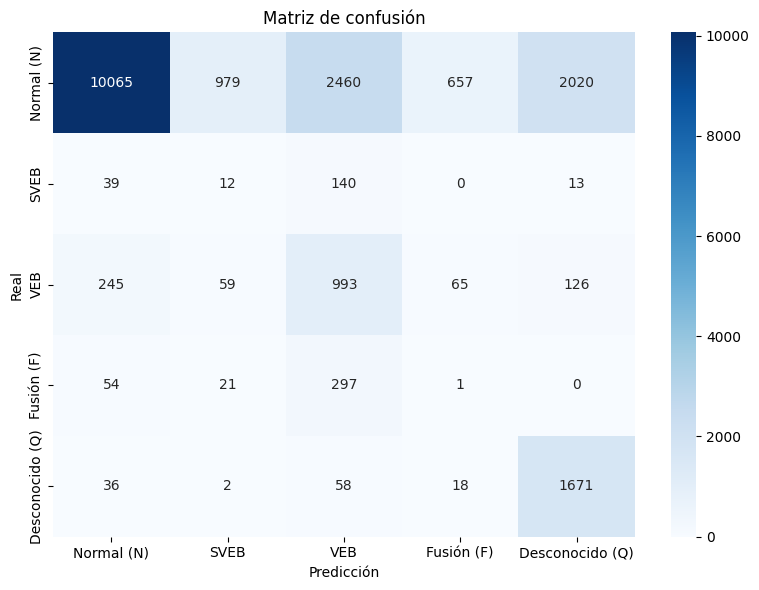

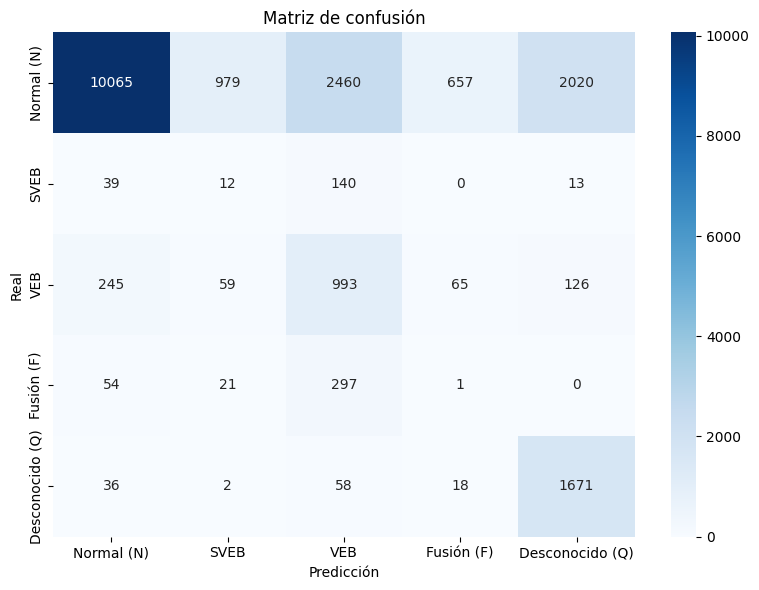

In [9]:
plot_confusion(y_test, y_test_pred, class_names, normalize=False)

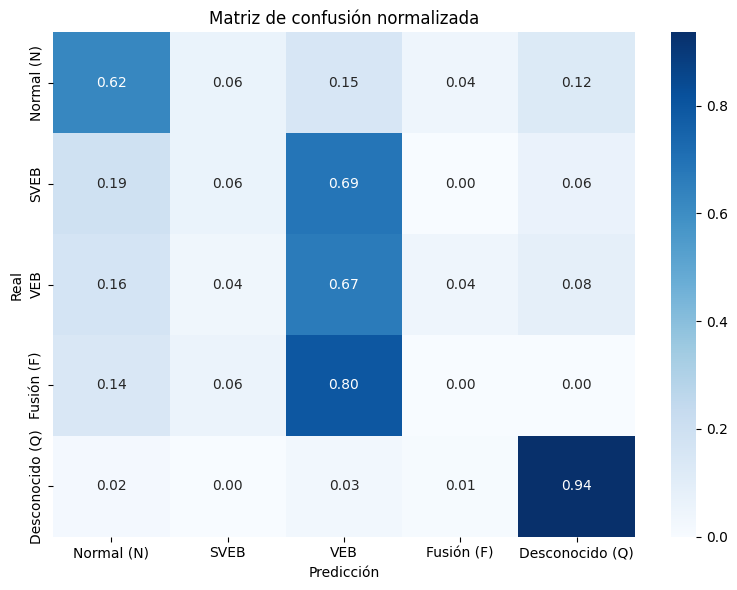

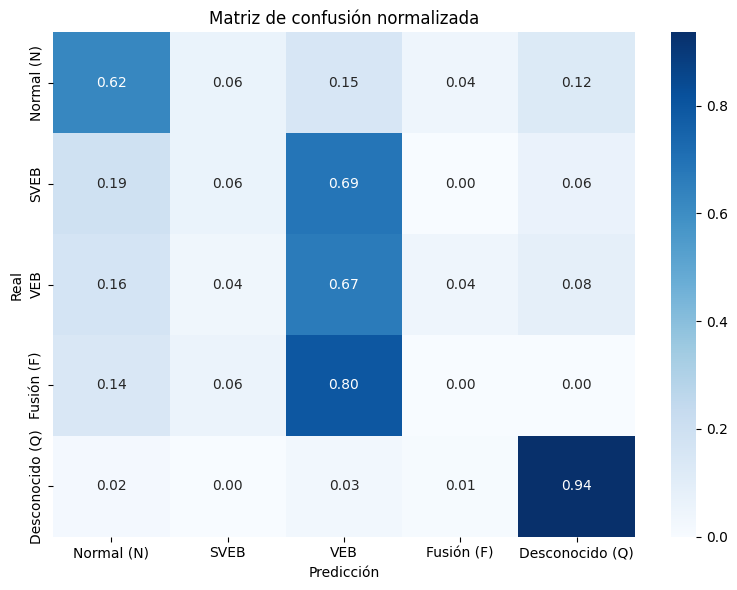

In [10]:
plot_confusion(y_test, y_test_pred, class_names, normalize=True)

## XAI en sistema de dos ramas

En v3 inspeccionamos por separado:
- atribuciones HRV
- atribuciones morfológicas
- relevancia temporal por oclusión en cada rama

In [13]:
sample_idx = 0
sample_inputs = {
    "hrv_input": X_hrv_test[sample_idx:sample_idx+1],
    "morph_input": X_morph_test[sample_idx:sample_idx+1],
}

sal = saliency_map(best_model, sample_inputs)
ig = integrated_gradients(best_model, sample_inputs, steps=32)
occ = temporal_occlusion_importance(best_model, sample_inputs, window=1)

print({k: np.asarray(v).shape for k, v in sal.items()})
print({k: np.asarray(v).shape for k, v in ig.items()})
print({k: np.asarray(v).shape for k, v in occ.items()})

ValueError: Layer "v3_dual_branch_recurrent" expects 2 input(s), but it received 1 input tensors. Inputs received: [<tf.Tensor: shape=(1, 20, 8), dtype=float32, numpy=
array([[[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0

NameError: name 'ig' is not defined

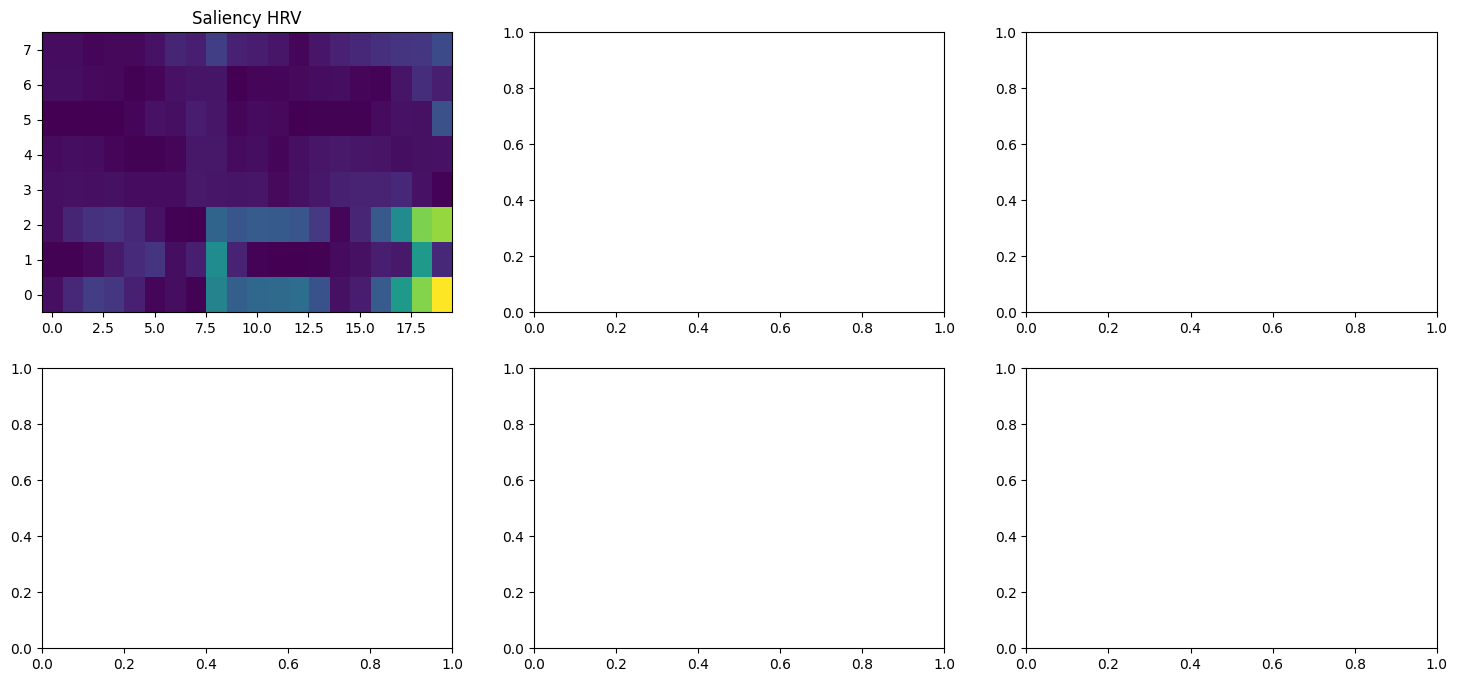

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

axes[0, 0].imshow(np.abs(sal["hrv_input"][0]).T, aspect="auto", origin="lower")
axes[0, 0].set_title("Saliency HRV")

axes[0, 1].imshow(np.abs(ig["hrv_input"][0]).T, aspect="auto", origin="lower")
axes[0, 1].set_title("IG HRV")

axes[0, 2].bar(np.arange(len(occ["hrv_input"])), occ["hrv_input"])
axes[0, 2].set_title("Occlusion HRV")

axes[1, 0].imshow(np.abs(sal["morph_input"][0]).T, aspect="auto", origin="lower")
axes[1, 0].set_title("Saliency Morph")

axes[1, 1].imshow(np.abs(ig["morph_input"][0]).T, aspect="auto", origin="lower")
axes[1, 1].set_title("IG Morph")

axes[1, 2].bar(np.arange(len(occ["morph_input"])), occ["morph_input"])
axes[1, 2].set_title("Occlusion Morph")

plt.tight_layout()
plt.show()

In [ ]:
metadata = {
    "model_version": "v3",
    "task": "next_beat_aami5_grouped",
    "class_names": class_names,
    "input_shapes": {
        "hrv_input": list(X_hrv_train.shape[1:]),
        "morph_input": list(X_morph_train.shape[1:]),
    },
    "feature_names_hrv": dataset["feature_names_hrv"],
    "feature_names_morph": dataset["feature_names_morph"],
    "split_protocol": "grouped_stratified_record_split",
    "selected_balance_strategy": best_cfg.balance_strategy,
    "loss_name": best_cfg.loss_name,
    "seed": best_cfg.random_state,
    "data_config": dataset["config"],
}

best_model.save(OUTPUT_DIR / "model.keras")
save_json(metadata, OUTPUT_DIR / "metadata.json")
save_json(eval_bundle, OUTPUT_DIR / "metrics_test.json")

## Cierre v3

La configuración elegida debe justificarse por:
- macro-F1
- consistencia por registro
- coste de inferencia razonable
- interpretabilidad más rica